# VAE results visulization

In [72]:
import sys
sys.path.append("/home/jovyan/fcvm-data-volume/kzzr229/workspace/counterfactual-benchmark/counterfactual_benchmark")
import torch
import numpy as np
from typing import Dict, List
from json import load
from importlib import import_module
from model import SCM
from tqdm import tqdm
import torch.nn as nn
from torch.utils.data import Dataset
import os
import numpy as np
import argparse
import random


from models.classifiers.classifier import Classifier
from models.classifiers.celeba_classifier import CelebaClassifier
from models.classifiers.celeba_complex_classifier import CelebaComplexClassifier
from models.classifiers.adni_classifier import ADNIClassifier
from ctf_datasets.morphomnist.dataset import MorphoMNISTLike
from ctf_datasets.celeba.dataset import Celeba
from ctf_datasets.adni.dataset import ADNI
from ctf_datasets.transforms import ReturnDictTransform, get_attribute_ids

from evaluation.metrics.composition import composition
from evaluation.metrics.minimality import minimality
from evaluation.embeddings.embeddings import get_embedding_model, get_embedding_fn
from evaluation.metrics.fid import fid
from evaluation.metrics.effectiveness import effectiveness
from evaluation.metrics.utils import save_selected_images, save_plots
from ctf_datasets.morphomnist.dataset import unnormalize as unnormalize_morphomnist
from ctf_datasets.celeba.dataset import unnormalize as unnormalize_celeba
from ctf_datasets.adni.dataset import unnormalize as unnormalize_adni

torch.multiprocessing.set_sharing_strategy('file_system')

rng = np.random.default_rng()

dataclass_mapping = {
    "morphomnist": (MorphoMNISTLike, unnormalize_morphomnist),
    "celeba": (Celeba, unnormalize_celeba),
    "adni": (ADNI, unnormalize_adni)
}

In [77]:
#config = './configs/celeba/complex/hvae.json'
#config = './configs/celeba/complex/vae.json'
config = './configs/celeba/complex/gan.json'
with open(config, 'r') as f:
    config = load(f)

dataset = config["dataset"]
attribute_size = config["attribute_size"]

models = {}
for variable in config["causal_graph"].keys():
    if variable not in config["mechanism_models"]:
        continue
    model_config = config["mechanism_models"][variable]

    module = import_module(model_config["module"])
    model_class = getattr(module, model_config["model_class"])
    model = model_class(params=model_config["params"], attr_size=attribute_size)

    models[variable] = model
    if "finetune" in model_config["params"] and model_config["params"]["finetune"] == 1:
        model.name += '_finetuned'

batch_size = config["mechanism_models"]["image"]["params"]["batch_size_val"]

scm = SCM(checkpoint_dir=config["checkpoint_dir"],
            graph_structure=config["causal_graph"],
            temperature=0.1,
            **models)

dataset = config["dataset"]
data_class, unnormalize_fn = dataclass_mapping[dataset]

transform = ReturnDictTransform(attribute_size)
test_set = data_class(attribute_size, split='test', transform=transform)

No_Beard_flow-epoch=00.ckpt
Bald_flow-epoch=00.ckpt
image_gan_finetuned-epoch=13.ckpt


label:  tensor([1., 1., 1., 0.])


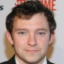

In [78]:
from torchvision import transforms
from PIL import Image
image_index=5694
batch = test_set[image_index]
img_tensor = batch['image']
to_pil = transforms.ToPILImage()
img = to_pil(img_tensor)
graph_structure = scm.graph_structure['image']
label = torch.cat([batch[pa] for pa in graph_structure], dim=0)
print('label: ',label)
img



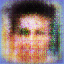

In [79]:
data_loader = torch.utils.data.DataLoader(test_set, batch_size=1, shuffle=False, num_workers=0)
device = model.device
intervention_tensor = torch.tensor([[1., 1., 1., 1.]]).to(device)
#for i , batch in tqdm(enumerate(data_loader)):

abducted_noise = scm.models['image'].encode(batch['image'].unsqueeze(0).to(device),label.unsqueeze(0).to(device))
decode_tensor = scm.models['image'].decode(abducted_noise,intervention_tensor)


decode_img = to_pil(decode_tensor.squeeze(0))
decode_img

In [44]:
abducted_noise[0]

[tensor([[[[ 0.0169]],
 
          [[ 0.0954]],
 
          [[-0.2844]],
 
          [[ 0.2049]],
 
          [[-0.2040]],
 
          [[-0.0675]],
 
          [[ 0.0249]],
 
          [[ 0.1026]],
 
          [[-0.0752]],
 
          [[ 0.0937]],
 
          [[-0.1407]],
 
          [[-0.0724]],
 
          [[-0.0172]],
 
          [[-0.0683]],
 
          [[-0.1043]],
 
          [[ 0.0680]]]], device='cuda:0'),
 tensor([[[[-0.4000]],
 
          [[ 0.0577]],
 
          [[-0.0236]],
 
          [[ 2.1282]],
 
          [[ 0.3397]],
 
          [[-0.0525]],
 
          [[-0.1471]],
 
          [[-0.7918]],
 
          [[ 0.1492]],
 
          [[-0.0263]],
 
          [[ 0.2887]],
 
          [[-0.1884]],
 
          [[-0.0740]],
 
          [[ 0.2121]],
 
          [[ 0.3158]],
 
          [[ 0.0812]]]], device='cuda:0'),
 tensor([[[[ 0.4207]],
 
          [[ 0.3833]],
 
          [[ 0.2008]],
 
          [[-0.1224]],
 
          [[ 0.2172]],
 
          [[-0.5080]],
 
          [[-0